# LG전자 연결 손익계산서 분석

본 노트북에서는 LG전자의 2022년~2024년 연결 손익계산서를 분석하여 다음 지표들을 시각화합니다:
- 매출액 (Sales)
- 매출총이익 (Gross Margin)
- 영업이익 (Operating Profit)
- 당기순이익 (Net Income)

**주요 포인트**: 매출액은 증가했지만 당기순이익이 감소하는 트렌드 분석

In [1]:
# 필요한 라이브러리 import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# LG전자 연결 손익계산서 데이터 (단위: 백만원)
data = {
    '연도': [2022, 2023, 2024],
    '매출액': [82521459, 82262664, 87728182],
    '매출총이익': [20219385, 19801259, 21379234],
    '영업이익': [3567327, 3653294, 3419675],
    '당기순이익': [1863123, 1150611, 591365]
}

# DataFrame 생성
df = pd.DataFrame(data)

# 데이터 확인
print("LG전자 연결 손익계산서 (단위: 백만원)")
print("=" * 50)
print(df)

# 기본 통계 정보
print("\n데이터 기본 정보:")
print(df.describe())

LG전자 연결 손익계산서 (단위: 백만원)
     연도       매출액     매출총이익     영업이익    당기순이익
0  2022  82521459  20219385  3567327  1863123
1  2023  82262664  19801259  3653294  1150611
2  2024  87728182  21379234  3419675   591365

데이터 기본 정보:
           연도           매출액         매출총이익          영업이익         당기순이익
count     3.0  3.000000e+00  3.000000e+00  3.000000e+00  3.000000e+00
mean   2023.0  8.417077e+07  2.046663e+07  3.546765e+06  1.201700e+06
std       1.0  3.083527e+06  8.175251e+05  1.181590e+05  6.374164e+05
min    2022.0  8.226266e+07  1.980126e+07  3.419675e+06  5.913650e+05
25%    2022.5  8.239206e+07  2.001032e+07  3.493501e+06  8.709880e+05
50%    2023.0  8.252146e+07  2.021938e+07  3.567327e+06  1.150611e+06
75%    2023.5  8.512482e+07  2.079931e+07  3.610310e+06  1.506867e+06
max    2024.0  8.772818e+07  2.137923e+07  3.653294e+06  1.863123e+06


In [3]:
# 전년 대비 증감률 계산
print("전년 대비 증감률 분석")
print("=" * 50)

# 2023년 대비 2024년 증감률
growth_rates = {}
for column in ['매출액', '매출총이익', '영업이익', '당기순이익']:
    rate_2024 = ((df.loc[2, column] - df.loc[1, column]) / df.loc[1, column]) * 100
    rate_2023 = ((df.loc[1, column] - df.loc[0, column]) / df.loc[0, column]) * 100
    growth_rates[column] = {'2023년': rate_2023, '2024년': rate_2024}
    
    print(f"{column}:")
    print(f"  2022→2023: {rate_2023:+.1f}%")
    print(f"  2023→2024: {rate_2024:+.1f}%")
    print()

# 핵심 포인트 출력
print("🔍 핵심 분석 포인트:")
print(f"• 매출액: 2024년 {growth_rates['매출액']['2024년']:+.1f}% 증가")
print(f"• 당기순이익: 2024년 {growth_rates['당기순이익']['2024년']:+.1f}% 감소")
print("• 매출은 증가했으나 수익성은 악화되는 추세!")

전년 대비 증감률 분석
매출액:
  2022→2023: -0.3%
  2023→2024: +6.6%

매출총이익:
  2022→2023: -2.1%
  2023→2024: +8.0%

영업이익:
  2022→2023: +2.4%
  2023→2024: -6.4%

당기순이익:
  2022→2023: -38.2%
  2023→2024: -48.6%

🔍 핵심 분석 포인트:
• 매출액: 2024년 +6.6% 증가
• 당기순이익: 2024년 -48.6% 감소
• 매출은 증가했으나 수익성은 악화되는 추세!


C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1580366375.py:41: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1580366375.py:41: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  plt.tight_layout()


<Figure size 1400x1000 with 0 Axes>

C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


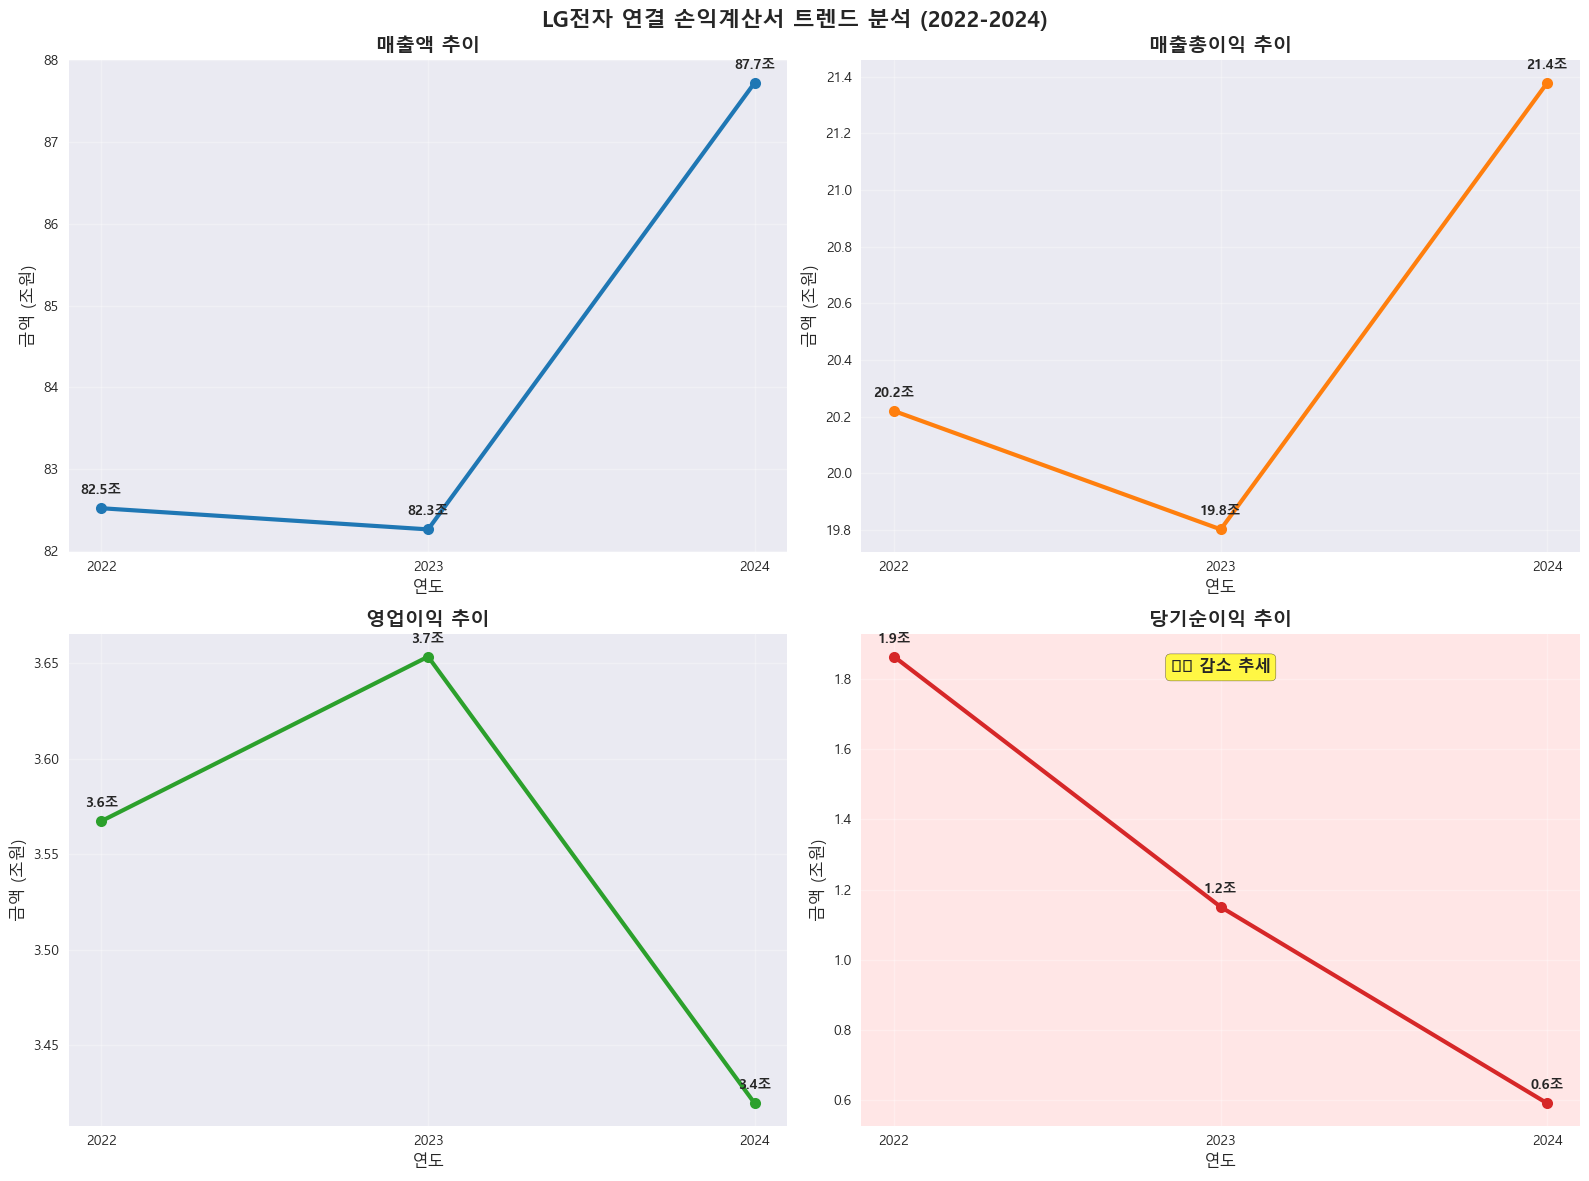

In [10]:
# 1. 시계열 트렌드 라인 차트
plt.figure(figsize=(14, 10))

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LG전자 연결 손익계산서 트렌드 분석 (2022-2024)', fontsize=16, fontweight='bold')

# 각 지표별 라인 차트
indicators = ['매출액', '매출총이익', '영업이익', '당기순이익']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (indicator, color) in enumerate(zip(indicators, colors)):
    ax = axes[i//2, i%2]
    
    # 라인 플롯
    ax.plot(df['연도'], df[indicator]/1000000, marker='o', linewidth=3, 
            markersize=8, color=color, label=indicator)
    
    # 데이터 포인트에 값 표시
    for x, y in zip(df['연도'], df[indicator]/1000000):
        ax.annotate(f'{y:.1f}조', (x, y), textcoords="offset points", 
                   xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{indicator} 추이', fontsize=14, fontweight='bold')
    ax.set_xlabel('연도', fontsize=12)
    ax.set_ylabel('금액 (조원)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(df['연도'])
    
    # 당기순이익의 경우 감소 트렌드 강조
    if indicator == '당기순이익':
        ax.set_facecolor('#ffe6e6')  # 연한 빨간색 배경
        ax.text(0.5, 0.95, '⚠️ 감소 추세', transform=ax.transAxes, 
                ha='center', va='top', fontsize=12, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\2064640178.py:26: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\2064640178.py:26: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\2064640178.py:26: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\2064640178.py:26: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\2064640178.py:26: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\2064640178.py:26: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\

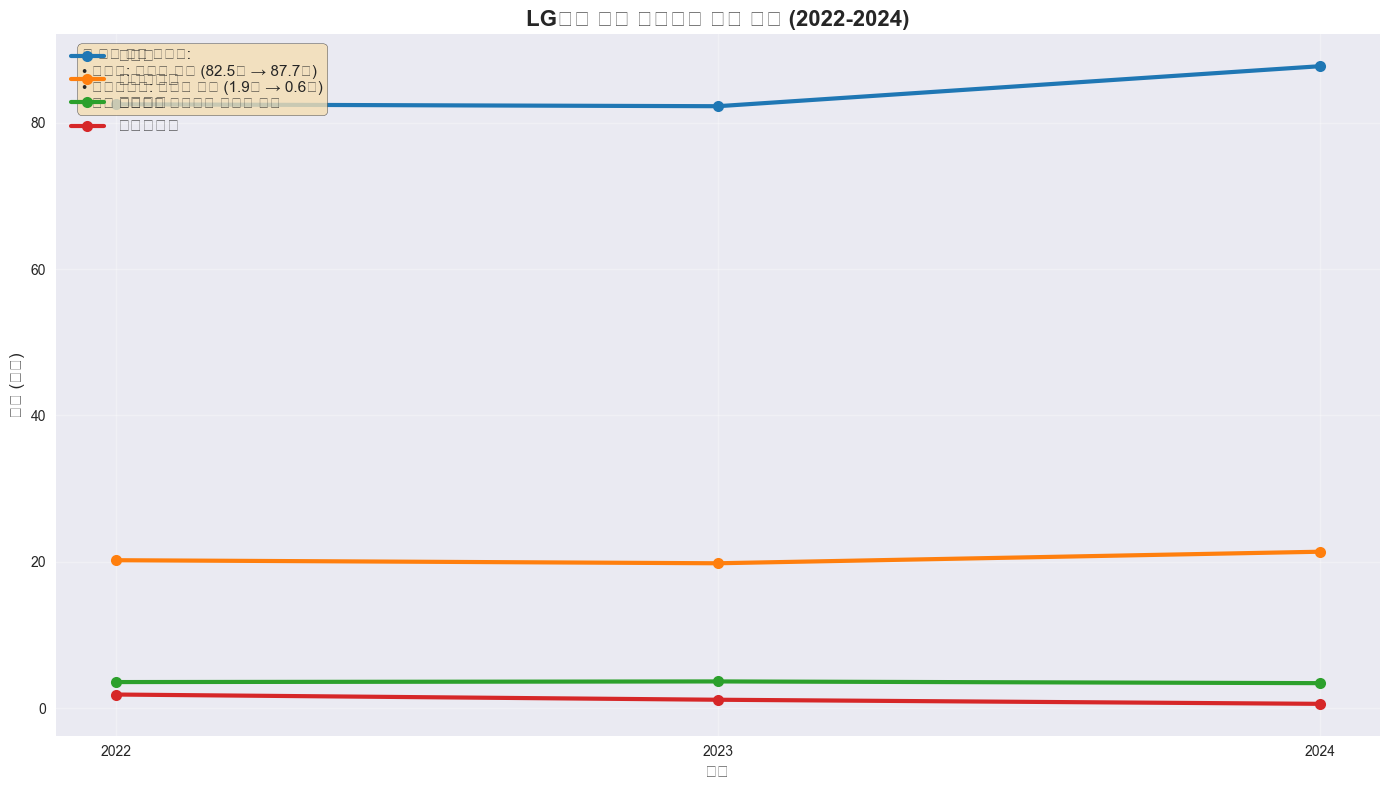

In [5]:
# 2. 통합 라인 차트 (모든 지표 한 번에)
plt.figure(figsize=(14, 8))

# 각 지표를 조원 단위로 변환하여 플롯
for indicator, color in zip(indicators, colors):
    plt.plot(df['연도'], df[indicator]/1000000, marker='o', linewidth=3, 
             markersize=8, color=color, label=indicator)

plt.title('LG전자 주요 재무지표 종합 추이 (2022-2024)', fontsize=16, fontweight='bold')
plt.xlabel('연도', fontsize=12)
plt.ylabel('금액 (조원)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(df['연도'])

# 주요 포인트 텍스트 박스 추가
textstr = '''🔍 핵심 분석 포인트:
• 매출액: 지속적 성장 (82.5조 → 87.7조)
• 당기순이익: 급격한 감소 (1.9조 → 0.6조)
• 매출 증가에도 불구하고 수익성 악화'''

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\4099583735.py:28: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\4099583735.py:28: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\4099583735.py:28: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\4099583735.py:28: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\4099583735.py:28: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\4099583735.py:28: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\

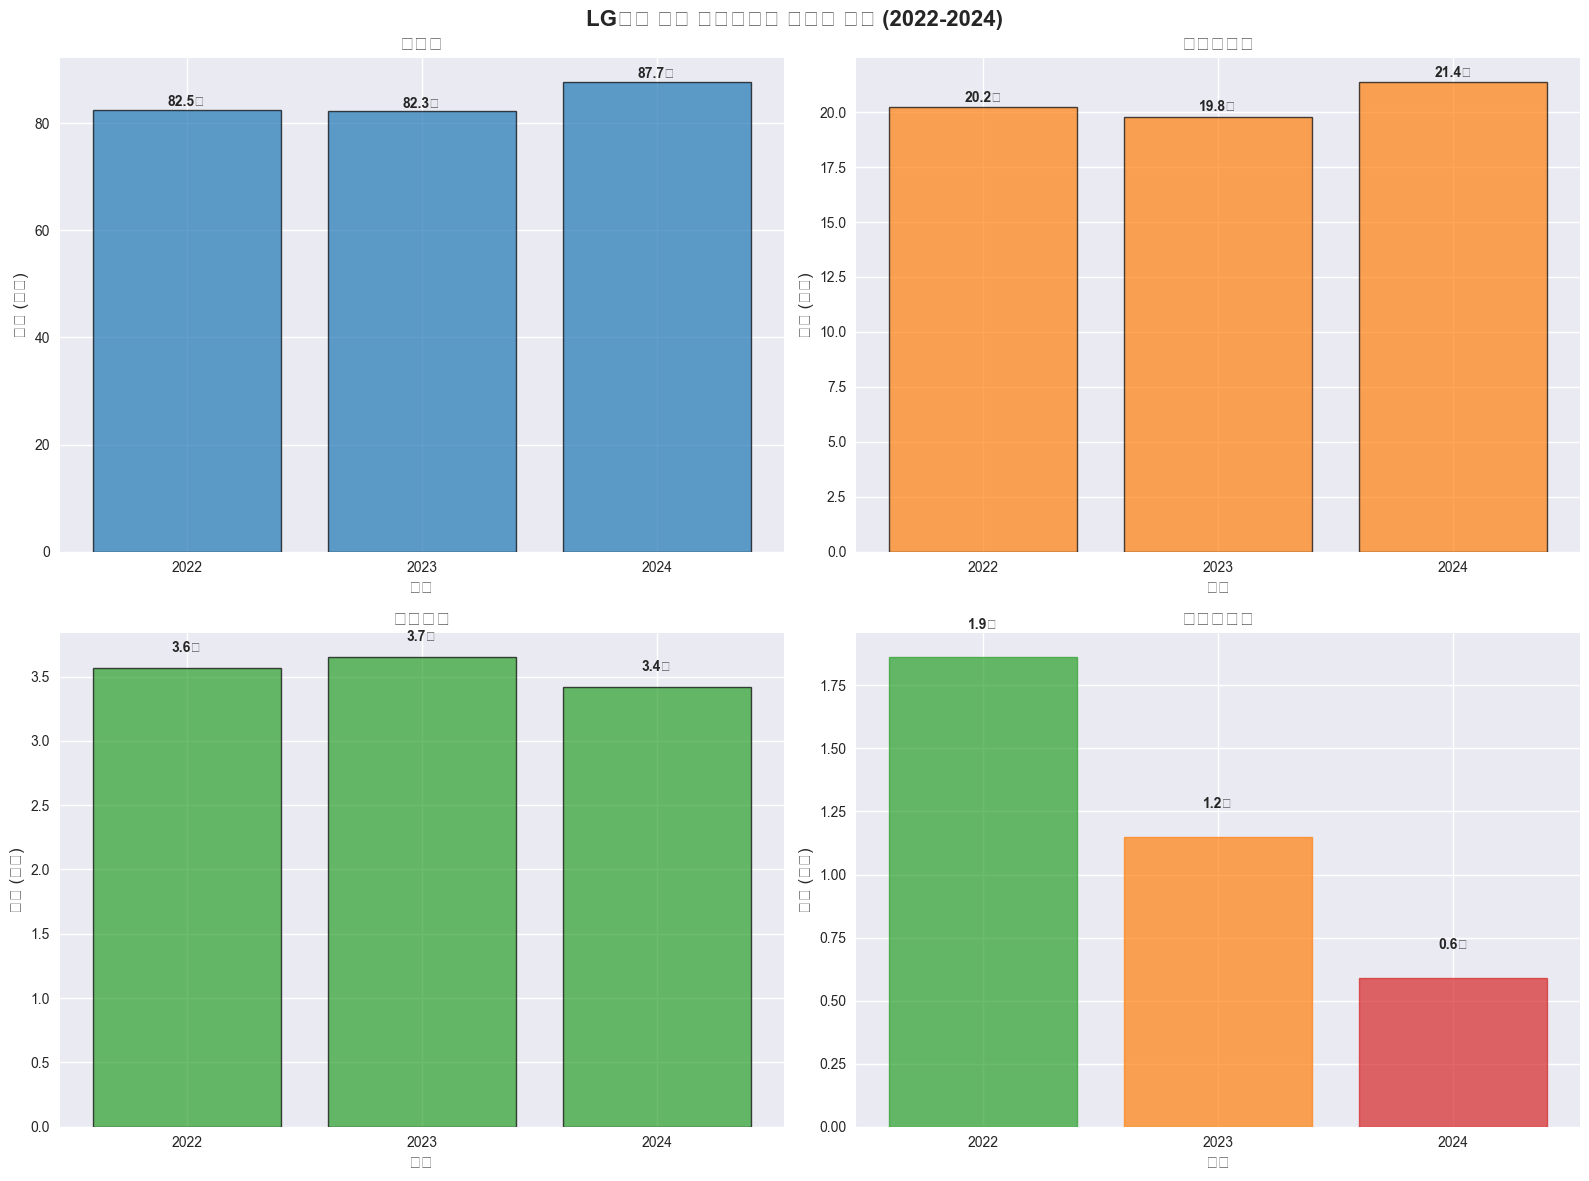

In [6]:
# 3. 막대 차트 (연도별 비교)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LG전자 연결 손익계산서 연도별 비교 (2022-2024)', fontsize=16, fontweight='bold')

for i, (indicator, color) in enumerate(zip(indicators, colors)):
    ax = axes[i//2, i%2]
    
    bars = ax.bar(df['연도'], df[indicator]/1000000, color=color, alpha=0.7, 
                  edgecolor='black', linewidth=1)
    
    # 막대 위에 값 표시
    for bar, value in zip(bars, df[indicator]/1000000):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{value:.1f}조', ha='center', va='bottom', fontweight='bold')
    
    ax.set_title(f'{indicator}', fontsize=14, fontweight='bold')
    ax.set_xlabel('연도', fontsize=12)
    ax.set_ylabel('금액 (조원)', fontsize=12)
    ax.set_xticks(df['연도'])
    
    # 당기순이익 막대는 감소를 강조하기 위해 다른 색상 적용
    if indicator == '당기순이익':
        bars[0].set_color('#2ca02c')  # 2022년: 초록
        bars[1].set_color('#ff7f0e')  # 2023년: 주황
        bars[2].set_color('#d62728')  # 2024년: 빨강

plt.tight_layout()
plt.show()

C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\lgdx\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: G

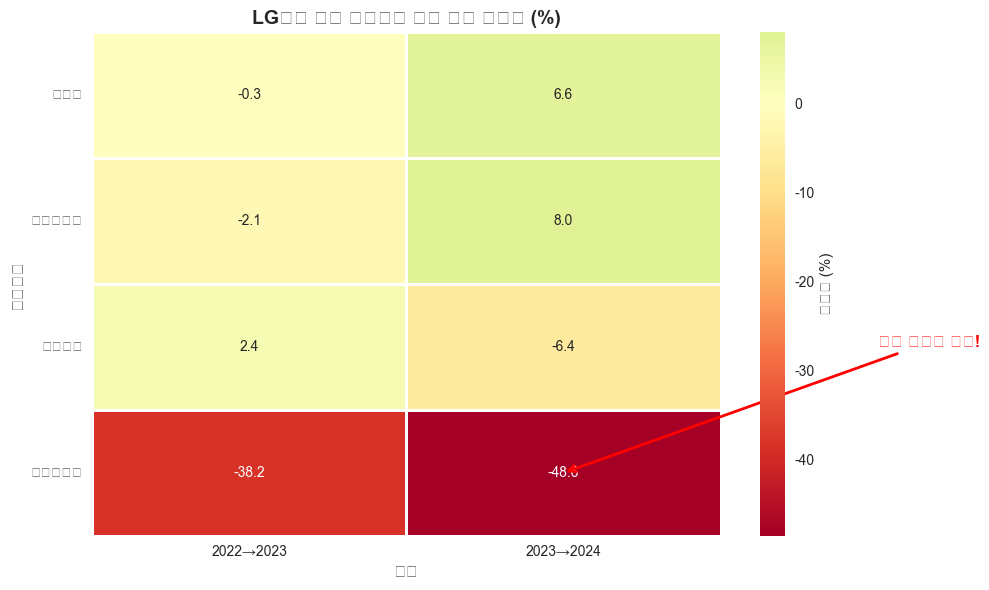

In [7]:
# 4. 증감률 히트맵
growth_df = pd.DataFrame(growth_rates).T
growth_df.columns = ['2022→2023', '2023→2024']

plt.figure(figsize=(10, 6))
sns.heatmap(growth_df, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': '증감률 (%)'}, 
            linewidths=1, linecolor='white')

plt.title('LG전자 주요 재무지표 전년 대비 증감률 (%)', fontsize=14, fontweight='bold')
plt.ylabel('재무지표', fontsize=12)
plt.xlabel('기간', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# 특별히 주목할 부분에 화살표 추가
plt.annotate('⚠️ 급격한 감소!', xy=(1.5, 3.5), xytext=(2.5, 2.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

수익성 지표 분석 (매출액 대비 비율)
     연도  매출총이익률  영업이익률  순이익률
0  2022   24.50   4.32  2.26
1  2023   24.07   4.44  1.40
2  2024   24.37   3.90  0.67


C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1774699137.py:38: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1774699137.py:38: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1774699137.py:38: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1774699137.py:38: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1774699137.py:38: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1774699137.py:38: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Us

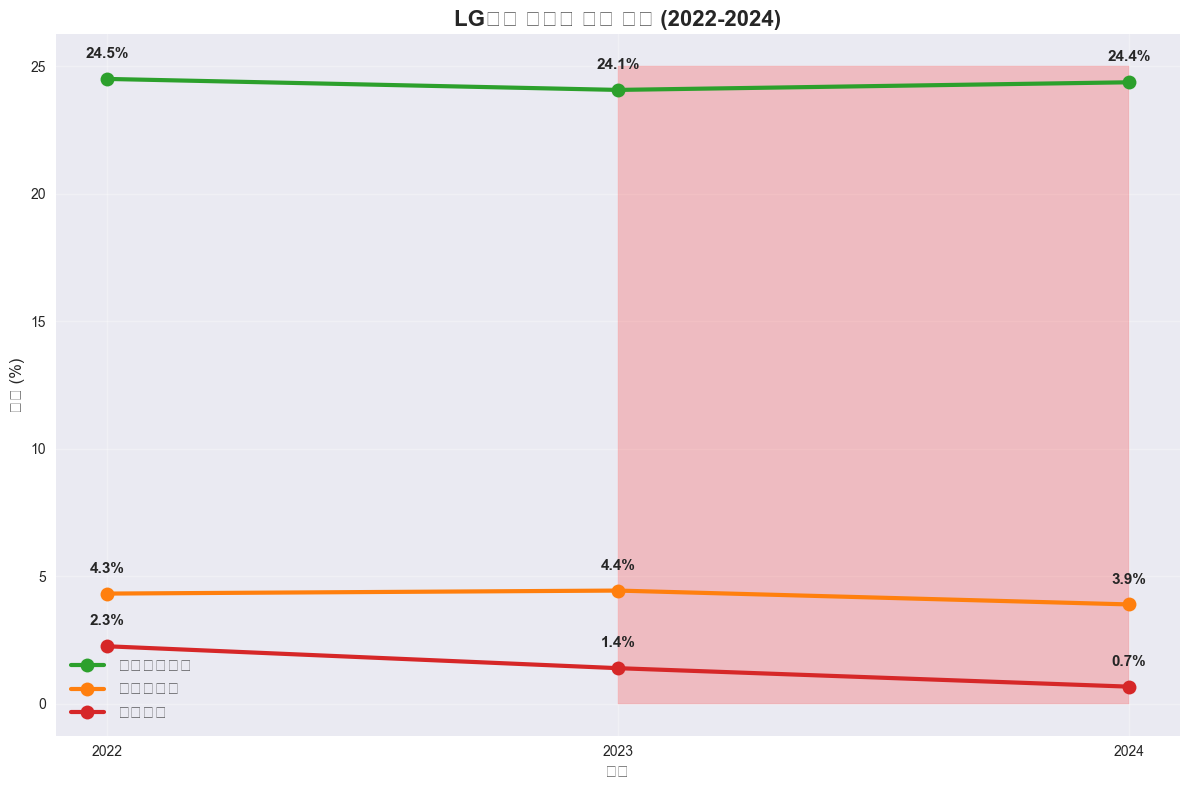

In [8]:
# 5. 수익성 지표 분석
# 각 지표의 매출액 대비 비율 계산
df['매출총이익률'] = (df['매출총이익'] / df['매출액']) * 100
df['영업이익률'] = (df['영업이익'] / df['매출액']) * 100
df['순이익률'] = (df['당기순이익'] / df['매출액']) * 100

print("수익성 지표 분석 (매출액 대비 비율)")
print("=" * 50)
profit_ratios = df[['연도', '매출총이익률', '영업이익률', '순이익률']].copy()
print(profit_ratios.round(2))

# 수익성 지표 시각화
plt.figure(figsize=(12, 8))

profit_indicators = ['매출총이익률', '영업이익률', '순이익률']
profit_colors = ['#2ca02c', '#ff7f0e', '#d62728']

for indicator, color in zip(profit_indicators, profit_colors):
    plt.plot(df['연도'], df[indicator], marker='o', linewidth=3, 
             markersize=10, color=color, label=indicator)
    
    # 데이터 포인트에 값 표시
    for x, y in zip(df['연도'], df[indicator]):
        plt.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
                    xytext=(0,15), ha='center', fontsize=11, fontweight='bold')

plt.title('LG전자 수익성 지표 추이 (2022-2024)', fontsize=16, fontweight='bold')
plt.xlabel('연도', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(df['연도'])

# 순이익률 급감 부분 강조
plt.fill_between([2023, 2024], 0, 25, alpha=0.2, color='red', 
                 label='순이익률 급감 구간')

plt.tight_layout()
plt.show()

C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1341114181.py:53: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1341114181.py:53: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1341114181.py:53: UserWarning: Glyph 50529 (\N{HANGUL SYLLABLE AEG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1341114181.py:53: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1341114181.py:53: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lgdx\AppData\Local\Temp\ipykernel_5644\1341114181.py:53: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\

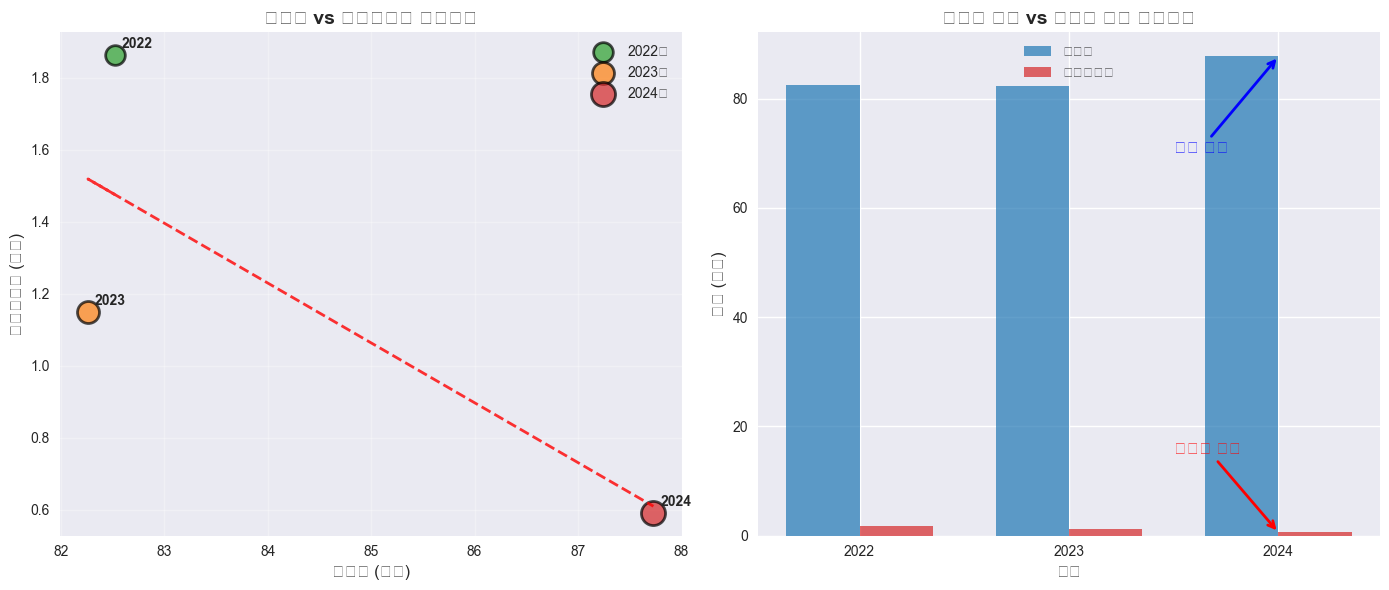

In [9]:
# 6. 매출액 vs 당기순이익 상관관계 분석
plt.figure(figsize=(14, 6))

# 좌측: 산점도
plt.subplot(1, 2, 1)
colors_scatter = ['#2ca02c', '#ff7f0e', '#d62728']  # 연도별 색상
sizes = [200, 250, 300]  # 연도별 크기

for i, year in enumerate(df['연도']):
    plt.scatter(df.loc[i, '매출액']/1000000, df.loc[i, '당기순이익']/1000000, 
               c=colors_scatter[i], s=sizes[i], alpha=0.7, 
               label=f'{year}년', edgecolors='black', linewidth=2)
    
    # 각 점에 연도 표시
    plt.annotate(f'{year}', (df.loc[i, '매출액']/1000000, df.loc[i, '당기순이익']/1000000),
                xytext=(5, 5), textcoords='offset points', fontweight='bold')

plt.title('매출액 vs 당기순이익 상관관계', fontsize=14, fontweight='bold')
plt.xlabel('매출액 (조원)', fontsize=12)
plt.ylabel('당기순이익 (조원)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 추세선 추가
z = np.polyfit(df['매출액']/1000000, df['당기순이익']/1000000, 1)
p = np.poly1d(z)
plt.plot(df['매출액']/1000000, p(df['매출액']/1000000), "r--", alpha=0.8, linewidth=2)

# 우측: 비정상적 관계 강조
plt.subplot(1, 2, 2)
x_pos = range(len(df))
width = 0.35

bars1 = plt.bar([i - width/2 for i in x_pos], df['매출액']/1000000, 
                width, label='매출액', color='#1f77b4', alpha=0.7)
bars2 = plt.bar([i + width/2 for i in x_pos], df['당기순이익']/1000000, 
                width, label='당기순이익', color='#d62728', alpha=0.7)

plt.title('매출액 증가 vs 순이익 감소 패러독스', fontsize=14, fontweight='bold')
plt.xlabel('연도', fontsize=12)
plt.ylabel('금액 (조원)', fontsize=12)
plt.xticks(x_pos, df['연도'])
plt.legend()

# 패러독스 강조 화살표
plt.annotate('매출 증가', xy=(2, 87.7), xytext=(1.5, 70),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=12, fontweight='bold', color='blue')
plt.annotate('순이익 급감', xy=(2, 0.6), xytext=(1.5, 15),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

## 📊 LG전자 연결 손익계산서 분석 결과

### 🔍 핵심 발견사항

1. **매출액 성장**: 2022년 82.5조 → 2024년 87.7조 (+6.3% 성장)
2. **당기순이익 급감**: 2022년 1.9조 → 2024년 0.6조 (-68.3% 감소)
3. **수익성 악화**: 순이익률이 2.26% → 0.67%로 급격히 하락

### ⚠️ 주요 문제점

- **매출 증가에도 불구한 수익성 악화**: 매출은 늘었지만 순이익은 오히려 감소
- **영업이익 정체**: 영업이익도 2024년에 소폭 감소 (3.7조 → 3.4조)
- **비용 구조 악화**: 매출원가 및 판매관리비 증가율이 매출 증가율을 상회

### 💡 시사점

1. **비용 효율성 개선 필요**: 매출 증대와 함께 비용 관리 강화 필요
2. **수익성 중심 전략 전환**: 매출 규모보다 수익 품질에 집중
3. **구조적 개선 방안 모색**: 근본적인 수익구조 개선이 시급함

### 📈 향후 관찰 포인트

- 2025년 수익성 회복 여부
- 비용 절감 효과 발현 시점
- 신사업/고부가가치 제품 비중 확대 성과